In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/used_cars.csv')
df.head()
print(df['fuel_type'].unique())

['E85 Flex Fuel' 'Gasoline' 'Hybrid' nan 'Diesel' 'Plug-In Hybrid' '–'
 'not supported']


In [3]:
# data cleaning
df = df[['model_year', 'milage', 'fuel_type',"accident", "price"]].dropna()
df_new = df[~df['fuel_type'].isin(["not supported", "–"])].copy()
df_new['price'] = df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df_new['milage'] = (
    df_new['milage']
    .str.replace(r'[^\d]', '', regex=True)  # keep only digits
    .astype(float)
)
# def simplify_fuel(x):
#     x = x.lower()
#     if 'gas' in x:
#         return 'gasoline'
#     elif 'hybrid' in x:
#         return 'hybrid'
#     elif 'electric' in x:
#         return 'electric'
#     else:
#         return 'other'

# df_new['fuel_type'] = df_new['fuel_type'].apply(simplify_fuel)
df_new['fuel_type'] = df_new['fuel_type'].astype('category')
df_new['accident'] = df_new['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
current_year = 2026
df_new['age'] = current_year - df_new['model_year'].astype(int)
print(df_new.head())

   model_year   milage      fuel_type  accident    price  age
0        2013  51000.0  E85 Flex Fuel         1  10300.0   13
1        2021  34742.0       Gasoline         1  38005.0    5
2        2022  22372.0       Gasoline         0  54598.0    4
3        2015  88900.0         Hybrid         0  15500.0   11
4        2021   9835.0       Gasoline         0  34999.0    5


In [4]:
print(df_new['fuel_type'].unique())


['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Diesel', 'Plug-In Hybrid']
Categories (5, object): ['Diesel', 'E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Plug-In Hybrid']


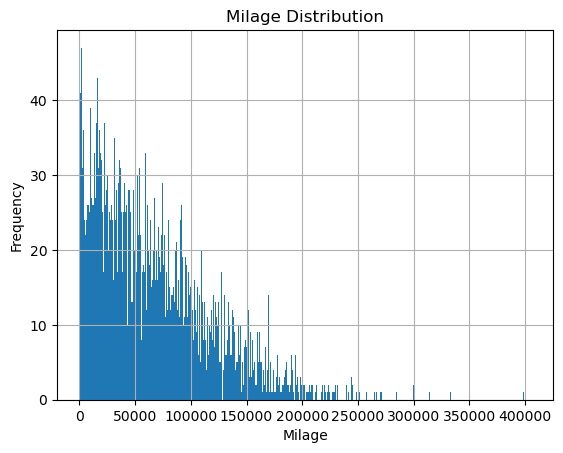

In [5]:
# visualizations
df_new["milage"].hist(bins=500)
plt.title('Milage Distribution')
plt.xlabel('Milage')
plt.ylabel('Frequency')
plt.show()

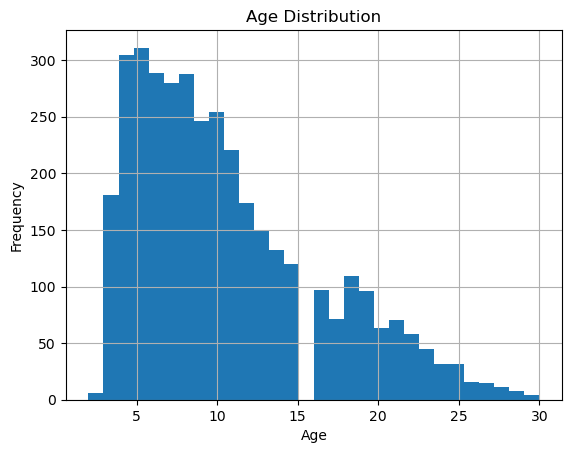

In [6]:
df_new["age"].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

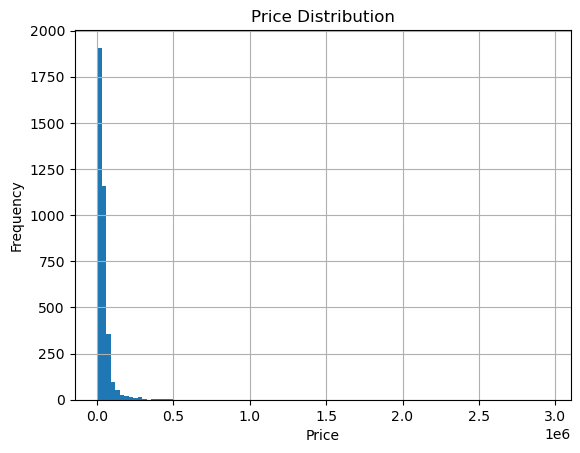

2954083.0


In [8]:
df_new["price"].hist(bins=100)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()
print(df_new['price'].max())
